In [7]:
from main import load_model_from_study
import spacy

import optuna

import torch.nn as nn
import torch

from torch.utils.data import DataLoader
from src.model import evaluate_model
from src.dataset import YelpDataset

from sklearn.metrics import accuracy_score

In [8]:
import numpy as np
import pandas as pd

In [9]:
NLP = spacy.load('en_core_web_lg')
NLP_DISABLE = ['ner', 'parser', 'attribute_ruler', 'lemmatizer', 'tagger']
MAX_SEQ_LEN = 100
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
READ_SIZE = 70000

In [10]:
# Optuna variables
study_name="sentiment_lstm_hpo"
direction="minimize"
storage="sqlite:///./models/sentiment_lstm_hpo.db"

# Load the optuna study
study = optuna.load_study(study_name=study_name, storage=storage)

In [11]:
model = load_model_from_study(study)
loss_fn = nn.CrossEntropyLoss()

In [12]:
df = pd.read_csv('./data/yelp_review_100k.csv', skiprows=range(1, READ_SIZE+1))
df['length'] = df['text'].apply(lambda x: len(x.split()))
df['y'] = np.array(df['sentiment'].map({'negative': 0, 'neutral': 1, 'positive': 2}))

In [13]:
df_grouped = df.groupby('length')

In [14]:
df_seq_acc = pd.DataFrame(columns=['seq_len', 'accuracy'])

In [15]:
for length, group in df_grouped:

    print (f'len {length}')


    tokenized_vectors = []
    
    # Tokenize sentences.
    for doc in NLP.pipe(group['text'], 
                        batch_size=10, 
                        disable=NLP_DISABLE, 
                        n_process=1
                        ):
        
        # Record the tokens that have a vector.
        sentence = []
        for token in doc:
            if token.has_vector:
                sentence.append(token.vector)

        # Append the vectorized sample.
        tokenized_vectors.append(np.array(sentence))

    group['embeddings'] = tokenized_vectors
    dataset = YelpDataset(group['embeddings'], group['y'], MAX_SEQ_LEN)
    loader =  DataLoader(dataset, batch_size=len(group['text']))

    group['y_pred'], _, _ = evaluate_model(model, loader, loss_fn, DEVICE)

    acc = accuracy_score(group['y'], group['y_pred'])
    print (f'seq_len {length} acc {acc}')

    # Append the new sample using loc (recommended for adding rows one at a time)
    df_seq_acc.loc[len(df_seq_acc)] = [length, acc]

len 1


Evaluating: 100%|██████████| 1/1 [00:00<00:00,  8.67it/s]


seq_len 1 acc 0.0
len 2


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 125.35it/s]


seq_len 2 acc 1.0
len 3


...

len 959


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 111.41it/s]


seq_len 959 acc 1.0
len 974


Evaluating: 100%|██████████| 1/1 [00:00<00:00, 200.42it/s]

seq_len 974 acc 0.0


In [21]:
import matplotlib.pyplot as plt

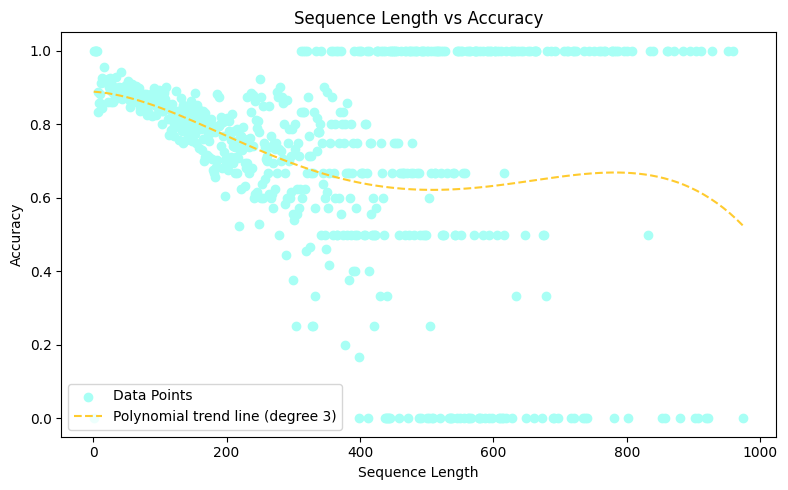

In [ ]:
pts_clr = '#0d7c9e'
trend_ln_clr = '#ffcb2e'

plt.figure(figsize=(8, 5))
plt.scatter(df_seq_acc['seq_len'], df_seq_acc['accuracy'], color=pts_clr, label='Data Points')


# Fit a polynomial of degree 2 (quadratic) to the data
z = np.polyfit(df_seq_acc['seq_len'], df_seq_acc['accuracy'], 4)  # Change degree if necessary
p = np.poly1d(z)

# Plot the polynomial trend line
x_range = np.linspace(df_seq_acc['seq_len'].min(), df_seq_acc['seq_len'].max(), 100)
plt.plot(x_range, p(x_range), color=trend_ln_clr, linestyle='--', label='Polynomial trend line (degree 3)')



plt.title('Sequence Length vs Accuracy')
plt.xlabel('Sequence Length')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()